# Cross-Run Model Comparison

Compare extraction results across different models and configurations on the **612-doc test set** (proper train/val/test split, no data leakage).

Each run is identified by its `run_id` (timestamp) and has a corresponding manifest in `results/`.

In [1]:
import json
import re
import sys
from collections import defaultdict
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

REPO_ROOT = Path.cwd().parent
RESULTS_DIR = REPO_ROOT / "results"
EXTRACTION_DIR = RESULTS_DIR / "triple_extraction" / "extraction"

# Add src to path so we can import from the pipeline
sys.path.insert(0, str(REPO_ROOT / "src"))
from cti_analysis.ontology import DNRTI_LABEL_TO_STIX, TYPES, PREDS

# --- Evaluation helpers (inlined) ---

FUZZY_THRESHOLD = 0.70

def normalize(text: str) -> str:
    """Normalize entity text for matching."""
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s-]', '', text)
    return text

def entity_match(gold: str, pred: str) -> bool:
    """Check if gold and predicted entities match (exact or fuzzy)."""
    g, p = normalize(gold), normalize(pred)
    if g == p:
        return True
    if g in p or p in g:
        return True
    return SequenceMatcher(None, g, p).ratio() >= FUZZY_THRESHOLD

def compute_metrics(gold_set: set, pred_set: set) -> dict:
    """Compute precision, recall, F1 with fuzzy entity matching."""
    tp = 0
    matched_gold = set()
    matched_pred = set()
    for p in pred_set:
        for g in gold_set:
            if g not in matched_gold and entity_match(g, p):
                tp += 1
                matched_gold.add(g)
                matched_pred.add(p)
                break
    fp = len(pred_set) - tp
    fn = len(gold_set) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}

## Run Registry

Auto-discover runs from manifest files. Each manifest contains the model name, config, and run ID.

In [2]:
# Auto-discover all manifests
manifests = {}
for mf in sorted(RESULTS_DIR.glob("*_manifest.json")):
    m = json.loads(mf.read_text(encoding="utf-8"))
    run_id = m["run_id"]
    # Check that extraction results exist
    ext_path = EXTRACTION_DIR / f"{run_id}.jsonl"
    if not ext_path.exists():
        ext_path = EXTRACTION_DIR / f"{run_id}.json"
    if ext_path.exists():
        manifests[run_id] = {**m, "extraction_path": ext_path}

print(f"Found {len(manifests)} runs with manifests and extraction results:\n")
for rid, m in manifests.items():
    print(f"  {rid}: model={m['model']}, dataset_mode={m.get('dataset_mode', '?')}")

Found 3 runs with manifests and extraction results:

  20260310-120451: model=gemma3-cti, dataset_mode=sentence
  20260310-132346: model=gemma3:12b, dataset_mode=sentence
  20260310-143757: model=gemma3-cti-f16, dataset_mode=sentence


## Load Gold Annotations

In [3]:
TEST_SET = REPO_ROOT / "results" / "finetuning" / "data" / "test_dnrti.json"
test_data = json.loads(TEST_SET.read_text(encoding="utf-8"))

# Build gold entity sets per doc_id
gold = {}
for i, entry in enumerate(test_data):
    doc_id = f"dnrti_{i}"
    entities = entry.get("entities") or []
    gold_ents = set()
    for ent in entities:
        if isinstance(ent, list) and len(ent) >= 4:
            stix_type = DNRTI_LABEL_TO_STIX.get(ent[3])
            if stix_type is not None:
                gold_ents.add(normalize(ent[2]))
    gold[doc_id] = gold_ents

total_gold = sum(len(v) for v in gold.values())
docs_with_gold = sum(1 for v in gold.values() if v)
print(f"Test set: {len(test_data)} docs, {total_gold} gold entities across {docs_with_gold} docs")

Test set: 612 docs, 2247 gold entities across 612 docs


## Evaluate All Runs

In [4]:
def evaluate_run(extraction_path: Path, gold: dict) -> dict:
    """Evaluate a single extraction run against gold annotations.
    Returns micro/macro metrics and per-doc details."""
    if extraction_path.suffix == ".jsonl":
        with open(extraction_path, encoding="utf-8") as f:
            batches = [json.loads(line) for line in f if line.strip()]
    else:
        batches = json.loads(extraction_path.read_text(encoding="utf-8"))

    all_gold, all_pred = set(), set()
    per_doc = []
    total_triples = 0

    for batch in batches:
        doc_id = batch.get("doc_id", "")
        triples = batch.get("triples", [])
        total_triples += len(triples)

        # Extract predicted entities from triples
        pred_ents = set()
        for t in triples:
            subj = t.get("subject", {})
            obj = t.get("object", {})
            s_name = subj.get("name") if isinstance(subj, dict) else subj
            o_name = obj.get("name") if isinstance(obj, dict) else obj
            if s_name:
                pred_ents.add(normalize(str(s_name)))
            if o_name:
                pred_ents.add(normalize(str(o_name)))

        gold_ents = gold.get(doc_id, set())
        metrics = compute_metrics(gold_ents, pred_ents)
        metrics["doc_id"] = doc_id
        metrics["num_triples"] = len(triples)
        metrics["num_gold"] = len(gold_ents)
        metrics["num_pred"] = len(pred_ents)
        per_doc.append(metrics)

        all_gold.update(gold_ents)
        all_pred.update(pred_ents)

    micro = compute_metrics(all_gold, all_pred)
    docs_eval = [d for d in per_doc if d["num_gold"] > 0]
    macro_p = np.mean([d["precision"] for d in docs_eval]) if docs_eval else 0
    macro_r = np.mean([d["recall"] for d in docs_eval]) if docs_eval else 0
    macro_f1 = np.mean([d["f1"] for d in docs_eval]) if docs_eval else 0

    return {
        "num_docs": len(batches),
        "total_triples": total_triples,
        "avg_triples": round(total_triples / max(1, len(batches)), 2),
        "micro_precision": micro["precision"],
        "micro_recall": micro["recall"],
        "micro_f1": micro["f1"],
        "micro_tp": micro["tp"],
        "micro_fp": micro["fp"],
        "micro_fn": micro["fn"],
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "per_doc": per_doc,
    }

# Evaluate all discovered runs
results = {}
for run_id, m in manifests.items():
    print(f"Evaluating {run_id} ({m['model']})...", end=" ")
    results[run_id] = evaluate_run(m["extraction_path"], gold)
    results[run_id]["model"] = m["model"]
    print(f"micro F1={results[run_id]['micro_f1']:.4f}, "
          f"macro F1={results[run_id]['macro_f1']:.4f}, "
          f"triples={results[run_id]['total_triples']}")

print(f"\nEvaluated {len(results)} runs.")

Evaluating 20260310-120451 (gemma3-cti)... 

micro F1=0.7199, macro F1=0.6636, triples=3065
Evaluating 20260310-132346 (gemma3:12b)... 

micro F1=0.7664, macro F1=0.6990, triples=1540
Evaluating 20260310-143757 (gemma3-cti-f16)... 

micro F1=0.7216, macro F1=0.6644, triples=3198

Evaluated 3 runs.


## Summary Table

In [5]:
# Build summary DataFrame
rows = []
for run_id, r in results.items():
    rows.append({
        "Run ID": run_id,
        "Model": r["model"],
        "Docs": r["num_docs"],
        "Triples": r["total_triples"],
        "Avg Trip/Doc": r["avg_triples"],
        "Micro P": round(r["micro_precision"], 4),
        "Micro R": round(r["micro_recall"], 4),
        "Micro F1": round(r["micro_f1"], 4),
        "Macro P": round(r["macro_precision"], 4),
        "Macro R": round(r["macro_recall"], 4),
        "Macro F1": round(r["macro_f1"], 4),
        "TP": r["micro_tp"],
        "FP": r["micro_fp"],
        "FN": r["micro_fn"],
    })

summary_df = pd.DataFrame(rows).sort_values("Micro F1", ascending=False).reset_index(drop=True)
summary_df.style.highlight_max(
    subset=["Micro F1", "Macro F1", "Micro P", "Micro R"],
    color="lightgreen"
).format({
    "Micro P": "{:.4f}", "Micro R": "{:.4f}", "Micro F1": "{:.4f}",
    "Macro P": "{:.4f}", "Macro R": "{:.4f}", "Macro F1": "{:.4f}",
})

,Run ID,Model,Docs,Triples,Avg Trip/Doc,Micro P,Micro R,Micro F1,Macro P,Macro R,Macro F1,TP,FP,FN
0,20260310-132346,gemma3:12b,612,1540,2.520000,0.7974,0.7378,0.7664,0.7524,0.6900,0.6990,968,246,344
1,20260310-143757,gemma3-cti-f16,612,3198,5.230000,0.8318,0.6372,0.7216,0.6542,0.7091,0.6644,836,169,476
2,20260310-120451,gemma3-cti,612,3065,5.010000,0.8418,0.6288,0.7199,0.6535,0.7092,0.6636,825,155,487


## Metric Comparison Charts

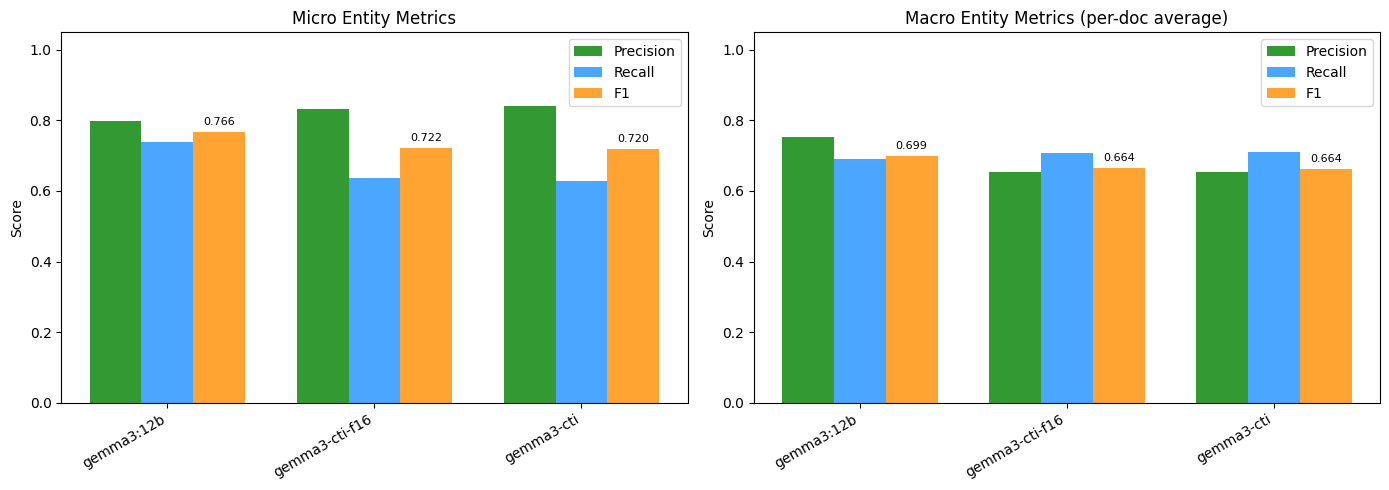

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = summary_df["Model"].tolist()
x = np.arange(len(models))
width = 0.25

# Chart 1: Micro metrics
ax = axes[0]
ax.bar(x - width, summary_df["Micro P"], width, label="Precision", color="green", alpha=0.8)
ax.bar(x, summary_df["Micro R"], width, label="Recall", color="dodgerblue", alpha=0.8)
ax.bar(x + width, summary_df["Micro F1"], width, label="F1", color="darkorange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Micro Entity Metrics")
ax.legend()
for i, row in summary_df.iterrows():
    ax.text(i + width, row["Micro F1"] + 0.02, f'{row["Micro F1"]:.3f}', ha="center", fontsize=8)

# Chart 2: Macro metrics
ax = axes[1]
ax.bar(x - width, summary_df["Macro P"], width, label="Precision", color="green", alpha=0.8)
ax.bar(x, summary_df["Macro R"], width, label="Recall", color="dodgerblue", alpha=0.8)
ax.bar(x + width, summary_df["Macro F1"], width, label="F1", color="darkorange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Macro Entity Metrics (per-doc average)")
ax.legend()
for i, row in summary_df.iterrows():
    ax.text(i + width, row["Macro F1"] + 0.02, f'{row["Macro F1"]:.3f}', ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## Per-Document F1 Distribution

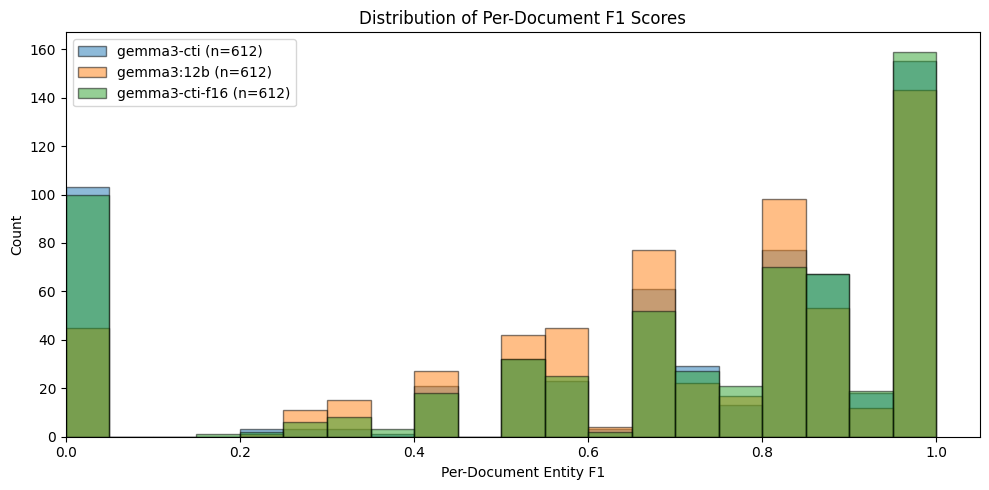

C:\Users\Bill\AppData\Local\Temp\ipykernel_35884\3282486966.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True)


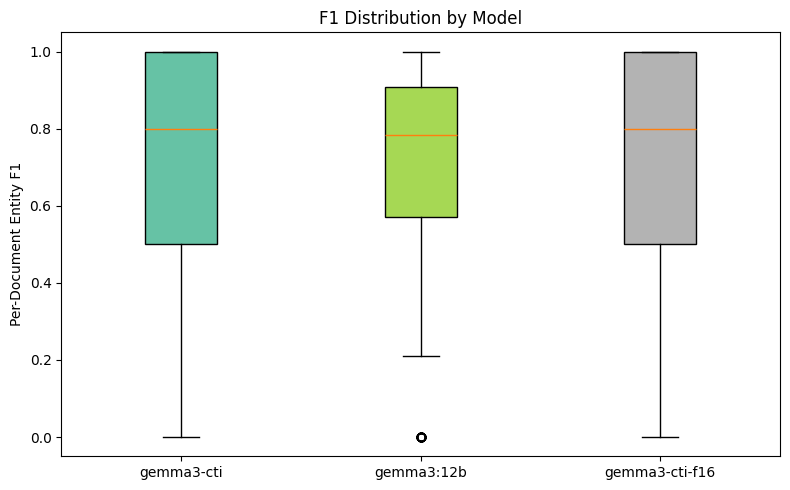

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

for run_id, r in results.items():
    f1_scores = [d["f1"] for d in r["per_doc"] if d["num_gold"] > 0]
    ax.hist(f1_scores, bins=20, alpha=0.5, label=f'{r["model"]} (n={len(f1_scores)})', edgecolor="black")

ax.set_xlabel("Per-Document Entity F1")
ax.set_ylabel("Count")
ax.set_title("Distribution of Per-Document F1 Scores")
ax.legend()
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

# Also show box plots
fig, ax = plt.subplots(figsize=(8, 5))
data_for_box = []
labels_for_box = []
for run_id, r in results.items():
    f1_scores = [d["f1"] for d in r["per_doc"] if d["num_gold"] > 0]
    data_for_box.append(f1_scores)
    labels_for_box.append(r["model"])

bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(data_for_box)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Per-Document Entity F1")
ax.set_title("F1 Distribution by Model")
plt.tight_layout()
plt.show()

## Head-to-Head: Per-Document Comparison

For each document, compare F1 across models. Highlights where one model wins vs the other.

gemma3-cti wins: 249 docs | gemma3:12b wins: 231 docs | Ties: 132 docs
Mean diff (gemma3-cti - gemma3:12b): -0.0354


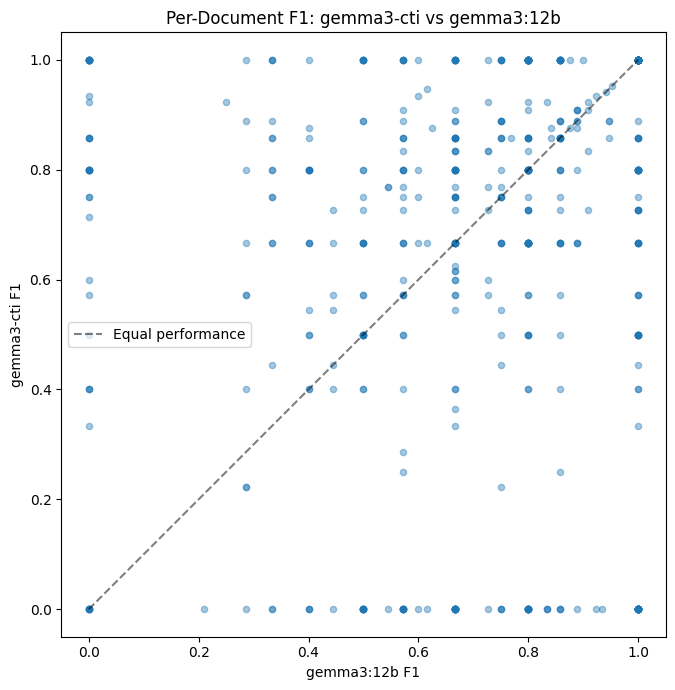


Top 10 docs where gemma3-cti > gemma3:12b:


,gemma3-cti,gemma3:12b,gemma3-cti-f16,diff
doc_id,,,,
dnrti_543,1.0,0.0,1.0,1.0
dnrti_409,1.0,0.0,1.0,1.0
dnrti_352,1.0,0.0,1.0,1.0
dnrti_388,1.0,0.0,1.0,1.0
dnrti_380,1.0,0.0,1.0,1.0
dnrti_389,1.0,0.0,1.0,1.0
dnrti_97,1.0,0.0,1.0,1.0
dnrti_261,1.0,0.0,1.0,1.0
dnrti_152,1.0,0.0,1.0,1.0



Top 10 docs where gemma3:12b > gemma3-cti:


,gemma3-cti,gemma3:12b,gemma3-cti-f16,diff
doc_id,,,,
dnrti_485,0.0,1.0,0.0,-1.0
dnrti_517,0.0,1.0,0.0,-1.0
dnrti_250,0.0,1.0,0.0,-1.0
dnrti_545,0.0,1.0,0.0,-1.0
dnrti_560,0.0,1.0,0.0,-1.0
dnrti_558,0.0,1.0,0.0,-1.0
dnrti_241,0.0,1.0,0.0,-1.0
dnrti_564,0.0,1.0,0.0,-1.0
dnrti_591,0.0,1.0,0.0,-1.0


In [8]:
# Build per-doc F1 DataFrame across all runs
per_doc_f1 = {}
for run_id, r in results.items():
    model = r["model"]
    per_doc_f1[model] = {d["doc_id"]: d["f1"] for d in r["per_doc"] if d["num_gold"] > 0}

f1_df = pd.DataFrame(per_doc_f1)
f1_df.index.name = "doc_id"

if len(results) >= 2:
    model_names = list(per_doc_f1.keys())
    m1, m2 = model_names[0], model_names[1]
    f1_df["diff"] = f1_df[m1] - f1_df[m2]
    f1_df_sorted = f1_df.sort_values("diff", ascending=False)

    wins_m1 = (f1_df["diff"] > 0).sum()
    wins_m2 = (f1_df["diff"] < 0).sum()
    ties = (f1_df["diff"] == 0).sum()
    print(f"{m1} wins: {wins_m1} docs | {m2} wins: {wins_m2} docs | Ties: {ties} docs")
    print(f"Mean diff ({m1} - {m2}): {f1_df['diff'].mean():.4f}")

    # Scatter plot
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(f1_df[m2], f1_df[m1], alpha=0.4, s=20)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Equal performance")
    ax.set_xlabel(f"{m2} F1")
    ax.set_ylabel(f"{m1} F1")
    ax.set_title(f"Per-Document F1: {m1} vs {m2}")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

    # Show biggest improvements and regressions
    print(f"\nTop 10 docs where {m1} > {m2}:")
    display(f1_df_sorted.head(10))
    print(f"\nTop 10 docs where {m2} > {m1}:")
    display(f1_df_sorted.tail(10))
else:
    print("Need at least 2 runs for head-to-head comparison.")
    display(f1_df.describe())

## Triple Count Comparison

Compare how many triples each model extracts per document.

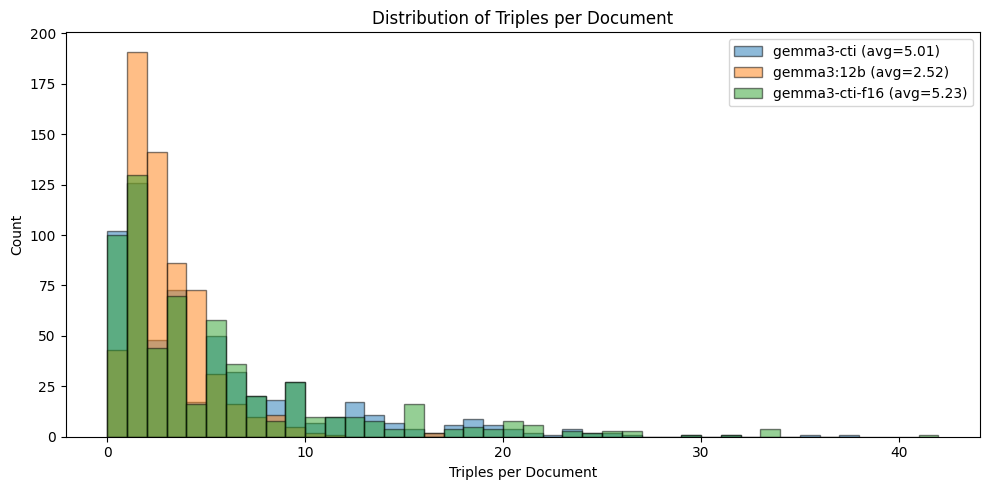

gemma3-cti: total=3065, avg=5.01, median=3, zero-triple docs=102/612
gemma3:12b: total=1540, avg=2.52, median=2, zero-triple docs=43/612
gemma3-cti-f16: total=3198, avg=5.23, median=3, zero-triple docs=100/612


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for run_id, r in results.items():
    triple_counts = [d["num_triples"] for d in r["per_doc"]]
    ax.hist(triple_counts, bins=range(0, max(triple_counts) + 2), alpha=0.5,
            label=f'{r["model"]} (avg={r["avg_triples"]})', edgecolor="black")

ax.set_xlabel("Triples per Document")
ax.set_ylabel("Count")
ax.set_title("Distribution of Triples per Document")
ax.legend()
plt.tight_layout()
plt.show()

# Summary stats
for run_id, r in results.items():
    triple_counts = [d["num_triples"] for d in r["per_doc"]]
    zero_docs = sum(1 for c in triple_counts if c == 0)
    print(f"{r['model']}: total={r['total_triples']}, avg={r['avg_triples']}, "
          f"median={np.median(triple_counts):.0f}, zero-triple docs={zero_docs}/{r['num_docs']}")

## Error Analysis: Docs Where Both Models Struggle

Documents where all models score F1 < 0.3 — candidates for qualitative review.

In [10]:
if len(results) >= 2 and f1_df is not None:
    model_cols = [c for c in f1_df.columns if c != "diff"]
    hard_docs = f1_df[model_cols].max(axis=1) < 0.3
    hard_df = f1_df[hard_docs].copy()
    print(f"Documents where ALL models score F1 < 0.3: {len(hard_df)}/{len(f1_df)}")
    if len(hard_df) > 0:
        # Show sample of hard docs with their gold entity count
        hard_df["gold_count"] = [len(gold.get(doc_id, set())) for doc_id in hard_df.index]
        display(hard_df.sort_values(model_cols[0]).head(20))
else:
    # Single model: show worst docs
    run_id = list(results.keys())[0]
    r = results[run_id]
    worst = sorted([d for d in r["per_doc"] if d["num_gold"] > 0], key=lambda d: d["f1"])[:20]
    print(f"20 worst-performing documents for {r['model']}:")
    display(pd.DataFrame(worst)[["doc_id", "f1", "precision", "recall", "num_triples", "num_gold"]])

Documents where ALL models score F1 < 0.3: 9/612


,gemma3-cti,gemma3:12b,gemma3-cti-f16,diff,gold_count
doc_id,,,,,
dnrti_62,0.0,0.210526,0.0,-0.210526,2
dnrti_245,0.0,0.000000,0.0,0.000000,2
dnrti_248,0.0,0.000000,0.0,0.000000,2
dnrti_259,0.0,0.285714,0.0,-0.285714,8
dnrti_280,0.0,0.000000,0.0,0.000000,8
dnrti_292,0.0,0.000000,0.0,0.000000,4
dnrti_318,0.0,0.000000,0.0,0.000000,2
dnrti_337,0.0,0.000000,0.0,0.000000,2
dnrti_494,0.0,0.000000,0.0,0.000000,2
